#  Interprétabilité — Détection de Fraude Bancaire
**Objectif :** Comprendre et expliquer les décisions du modèle XGBoost avec SHAP.

In [1]:
# 📦 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Modèles
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek

sns.set_theme(style="whitegrid")
shap.initjs()  # Initialise SHAP pour les graphiques
print("✅ Bibliothèques importées !")

✅ Bibliothèques importées !


In [2]:
# 📂 Chargement et préparation
df = pd.read_csv(r'C:\Users\emman\Documents\Portfolio\fraud-detection-ml\data\creditcard.csv')

# Feature Engineering
df['Hour']       = (df['Time'] / 3600) % 24
df['Amount_Log'] = np.log1p(df['Amount'])

# Séparation X et y
X = df.drop(['Class', 'Time'], axis=1)
y = df['Class']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42, stratify=y
)

# Normalisation
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test_scaled['Amount']  = scaler.transform(X_test[['Amount']])

# SMOTETomek
print("⏳ SMOTETomek en cours...")
smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(
    X_train_scaled, y_train
)
print("✅ Données prêtes !")

⏳ SMOTETomek en cours...
✅ Données prêtes !


In [3]:
# ⚡ Entraînement XGBoost
print("⏳ Entraînement XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train_res, y_train_res)
print("✅ XGBoost entraîné !")

⏳ Entraînement XGBoost...
✅ XGBoost entraîné !


In [4]:
# 🔍 Calcul des valeurs SHAP
print("⏳ Calcul des valeurs SHAP en cours...")
print("   (Cela peut prendre 2-3 minutes)\n")

# Créer l'explainer SHAP pour XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Calculer les valeurs SHAP sur un échantillon du test
# (on prend 1000 lignes pour aller plus vite)
X_test_sample = X_test_scaled.sample(1000, random_state=42)
shap_values   = explainer.shap_values(X_test_sample)

print("✅ Valeurs SHAP calculées !")
print(f"   Shape : {shap_values.shape}")

⏳ Calcul des valeurs SHAP en cours...
   (Cela peut prendre 2-3 minutes)

✅ Valeurs SHAP calculées !
   Shape : (1000, 31)


C:\Users\emman\AppData\Local\Temp\ipykernel_19720\3849741850.py:11: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_19720\3849741850.py:12: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.savefig('../reports/09_shap_importance.png',
C:\Users\emman\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


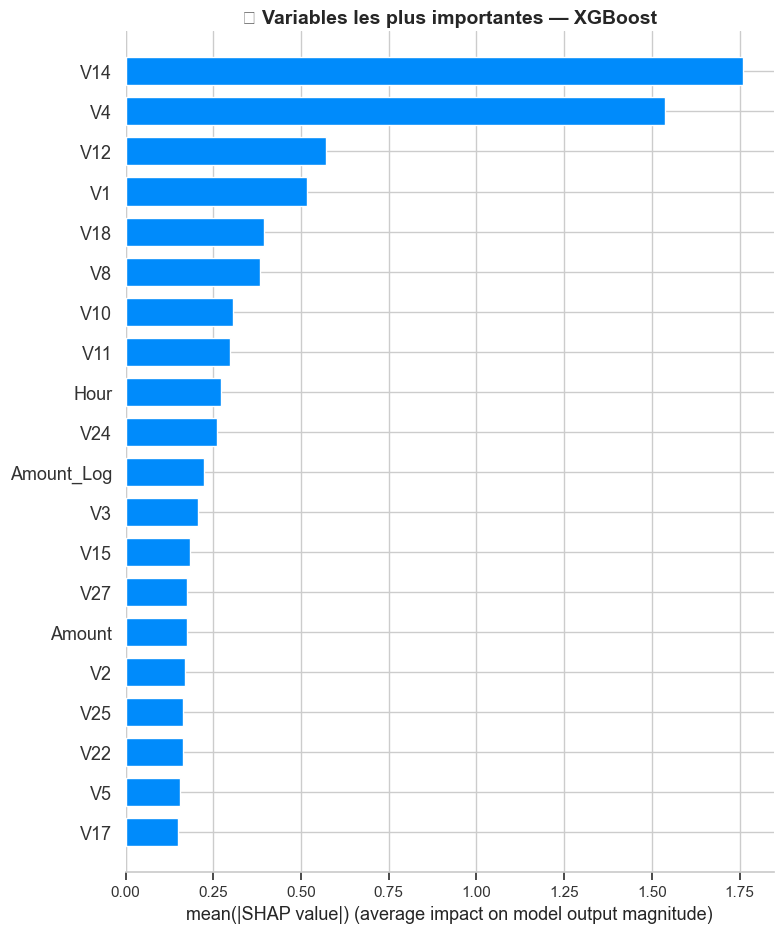

✅ Graphique sauvegardé !


In [5]:
# 📊 Graphique 1 : Importance des variables (SHAP)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type="bar",
    show=False
)
plt.title('🔍 Variables les plus importantes — XGBoost',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/09_shap_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé !")

C:\Users\emman\AppData\Local\Temp\ipykernel_19720\2211961468.py:10: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_19720\2211961468.py:11: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.savefig('../reports/10_shap_impact.png',
C:\Users\emman\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


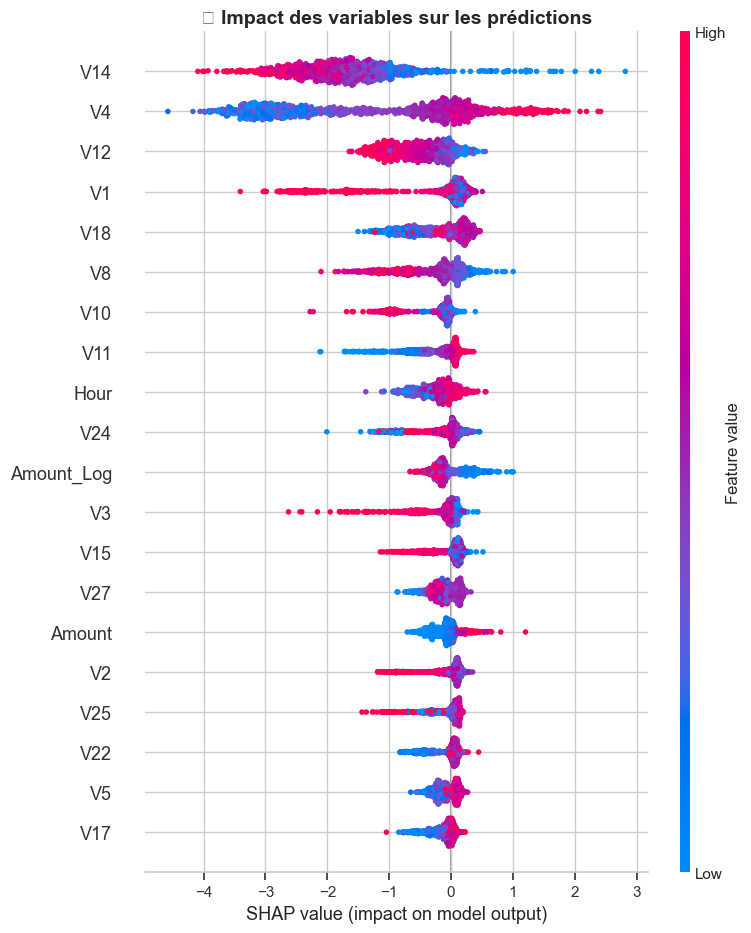

✅ Graphique sauvegardé !


In [6]:
# 📊 Graphique 2 : Impact détaillé de chaque variable
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_sample,
    show=False
)
plt.title('🔍 Impact des variables sur les prédictions',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/10_shap_impact.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé !")

🚨 Analyse d'une transaction frauduleuse :
   Probabilité de fraude : 99.97%


C:\Users\emman\AppData\Local\Temp\ipykernel_19720\2640176464.py:26: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_19720\2640176464.py:27: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.savefig('../reports/11_shap_waterfall_fraude.png',
C:\Users\emman\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


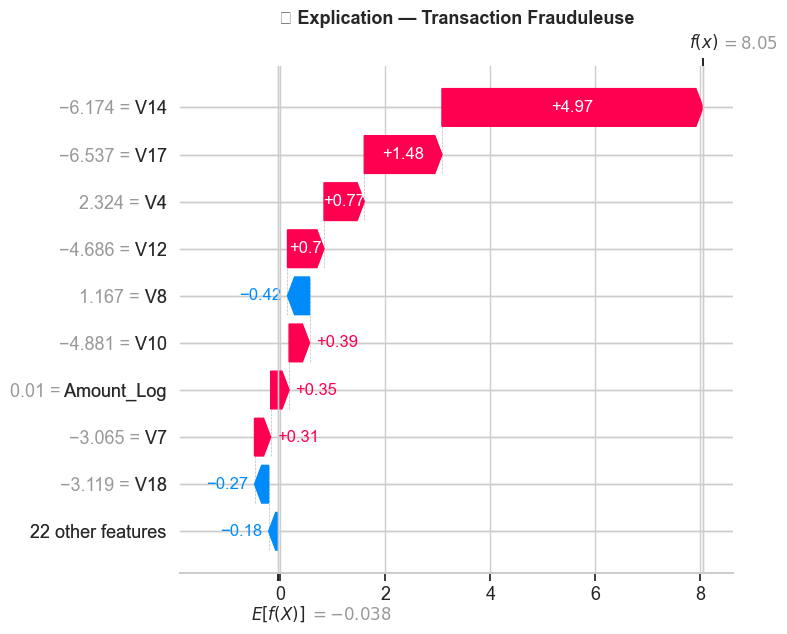

✅ Graphique sauvegardé !


In [7]:
# 🔍 Explication d'une transaction frauduleuse individuelle
# Trouver une vraie fraude dans le test
fraudes_idx = y_test[y_test == 1].index
X_fraude    = X_test_scaled.loc[fraudes_idx].iloc[0:1]

# Calculer les SHAP values pour cette transaction
shap_fraude = explainer.shap_values(X_fraude)

# Afficher l'explication
print("🚨 Analyse d'une transaction frauduleuse :")
print(f"   Probabilité de fraude : "
      f"{xgb_model.predict_proba(X_fraude)[0][1]:.2%}")

plt.figure(figsize=(12, 4))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_fraude[0],
        base_values=explainer.expected_value,
        data=X_fraude.iloc[0],
        feature_names=X_test_scaled.columns.tolist()
    ),
    show=False
)
plt.title('🚨 Explication — Transaction Frauduleuse',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/11_shap_waterfall_fraude.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé !")